# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/hands-on-multimodal-AI/blob/main/hands-on/HANDS_ON_session_01_multimodal_tokens_and_embeddings.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://www.oreilly.com/library/view/transformers-the-definitive/9781098167004/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="Transformers: The Definitive Guide"/>
</a>




<font color="red" size="10">
<b>HANDS-ON TIME: 10 mins</b>
</font>

# Simple Multimodal Tokenization (Image + Audio + Video)

This notebook is intentionally short.

Goal: **tokenize an image, an audio clip, and a short video** with Qwen2.5-Omni and inspect what the tokenizer/processor returns.

We keep only the essentials:
- one short video
- one extracted image frame
- one extracted audio clip
- token counts and placeholder-token inspection


## What you'll see

1. Build processor inputs for image + text, audio + text, and video + text
2. Print shapes of returned tensors (`input_ids`, `pixel_values`, `input_features`, etc.)
3. Count modality placeholder tokens (`<|IMAGE|>`, `<|AUDIO|>`) inside `input_ids`
4. Compare sequence lengths across modalities

## What you get from tokenization:

- The processor converts each modality into one token sequence (`input_ids`).
- `<|IMAGE|>` and `<|AUDIO|>` placeholders mark non-text content in that sequence.
- More visual/audio content usually means more placeholder tokens.
- These tokenized inputs are what the model consumes before generation.

In [12]:
!pip -q install -U "transformers==4.57.3" safetensors
!pip install -U "qwen-omni-utils[decord]" accelerate soundfile

In [13]:
import os
import base64
import subprocess
import warnings

import gdown
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import HTML, Audio, display

from transformers import Qwen2_5OmniForConditionalGeneration, Qwen2_5OmniProcessor
from qwen_omni_utils import process_mm_info

warnings.filterwarnings("ignore")



## Fetch one video and extract one image frame + one audio clip


Downloading...
From: https://drive.google.com/uc?id=17ZeTnfVoCC-uEioa5uQgTwPR_DFeD5Cd
To: /content/video_from_drive.mp4
100%|██████████| 285k/285k [00:00<00:00, 109MB/s]


Video: video_from_drive.mp4 (0.3 MB)
Image: frame_from_video.jpg
Audio: audio_from_video.wav (0.17 MB)


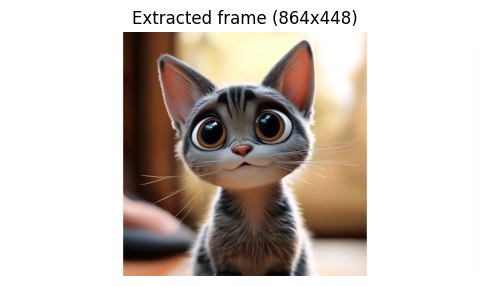

In [3]:

file_id = "17ZeTnfVoCC-uEioa5uQgTwPR_DFeD5Cd"
video_path = "video_from_drive.mp4"
frame_path = "frame_from_video.jpg"
audio_path = "audio_from_video.wav"

if not os.path.exists(video_path):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", video_path, quiet=False)
assert os.path.exists(video_path), "Video download failed"

# 1) Extract one frame (image)
subprocess.run(
    ["ffmpeg", "-y", "-i", video_path, "-vframes", "1", "-q:v", "2", frame_path, "-loglevel", "quiet"],
    check=True,
)
assert os.path.exists(frame_path), "Frame extraction failed"

# 2) Extract a short mono 16kHz audio clip (8 seconds max)
subprocess.run(
    [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-ac", "1", "-ar", "16000", "-t", "8",
        audio_path, "-loglevel", "quiet",
    ],
    check=True,
)
assert os.path.exists(audio_path), "Audio extraction failed"

print("Video:", video_path, f"({os.path.getsize(video_path)/1e6:.1f} MB)")
print("Image:", frame_path)
print("Audio:", audio_path, f"({os.path.getsize(audio_path)/1e6:.2f} MB)")

with open(video_path, "rb") as f:
    data_url = "data:video/mp4;base64," + base64.b64encode(f.read()).decode()
display(HTML(f'<video controls width="480" src="{data_url}"></video>'))

display(Audio(audio_path))

frame_img = Image.open(frame_path)
fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(frame_img)
ax.set_title(f"Extracted frame ({frame_img.size[0]}x{frame_img.size[1]})")
ax.axis("off")
plt.tight_layout()
plt.show()

## Install and load Qwen2.5-Omni

In [4]:
MODEL_ID = "Qwen/Qwen2.5-Omni-3B"

DEFAULT_OMNI_SYSTEM = (
    "You are Qwen, a virtual human developed by the Qwen Team, Alibaba Group, "
    "capable of perceiving auditory and visual inputs, as well as generating text and speech."
)

processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5OmniForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
)
model.disable_talker()
model.eval()

tokenizer = processor.tokenizer
image_tok_id = tokenizer.convert_tokens_to_ids("<|IMAGE|>")
audio_tok_id = tokenizer.convert_tokens_to_ids("<|AUDIO|>")

print("Device:", model.device)
print("image token id:", image_tok_id)
print("audio token id:", audio_tok_id)

preprocessor_config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

spk_dict.pt:   0%|          | 0.00/260k [00:00<?, ?B/s]

Device: cuda:0
image token id: 151655
audio token id: 151646


## Helper functions for token inspection

In [5]:

def pretty_token(tok: str) -> str:
    return tok.replace("Ġ", " ").replace("▁", " ")


def build_inputs(conversation, use_audio_in_video: bool):
    text = processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,
        system_prompt=DEFAULT_OMNI_SYSTEM,
    )
    audios, images, videos = process_mm_info(conversation, use_audio_in_video=use_audio_in_video)

    kwargs = {
        "text": text,
        "return_tensors": "pt",
        "padding": True,
        "use_audio_in_video": use_audio_in_video,
    }
    if audios is not None:
        kwargs["audio"] = audios
    if images is not None:
        kwargs["images"] = images
    if videos is not None:
        kwargs["videos"] = videos

    inputs = processor(**kwargs)
    return inputs.to(model.device).to(model.dtype)


def summarize_tokens(name: str, inputs):
    ids = inputs["input_ids"][0]
    tokens = tokenizer.convert_ids_to_tokens(ids.tolist())
    n_image = int((ids == image_tok_id).sum().item())
    n_audio = int((ids == audio_tok_id).sum().item())
    n_text = int(ids.shape[0] - n_image - n_audio)

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)
    for k, v in inputs.items():
        if hasattr(v, "shape"):
            print(f"{k:24s} shape={tuple(v.shape)} dtype={getattr(v, 'dtype', None)}")

    print("\nToken counts in input_ids")
    print("  total:", int(ids.shape[0]))
    print("  text:", n_text)
    print("  <|IMAGE|>:", n_image)
    print("  <|AUDIO|>:", n_audio)
    print("\nFirst 40 tokens:")
    print([pretty_token(t) for t in tokens[:40]])

    return {
        "name": name,
        "total": int(ids.shape[0]),
        "text": n_text,
        "image": n_image,
        "audio": n_audio,
    }

In [6]:

conversation_img = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": frame_path},
            {"type": "text", "text": "Describe this image in one sentence."},
        ],
    }
]

inputs_img = build_inputs(conversation_img, use_audio_in_video=False)
summary_img = summarize_tokens("IMAGE + TEXT", inputs_img)


IMAGE + TEXT
input_ids                shape=(1, 524) dtype=torch.int64
attention_mask           shape=(1, 524) dtype=torch.int64
pixel_values             shape=(1984, 1176) dtype=torch.bfloat16
image_grid_thw           shape=(1, 3) dtype=torch.int64

Token counts in input_ids
  total: 524
  text: 28
  <|IMAGE|>: 496
  <|AUDIO|>: 0

First 40 tokens:
['<|im_start|>', 'system', 'Ċ', 'You', ' are', ' a', ' helpful', ' assistant', '.', '<|im_end|>', 'Ċ', '<|im_start|>', 'user', 'Ċ', '<|vision_bos|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>', '<|IMAGE|>']


## Tokenize image + text

In [7]:

# Audio tokenization
conversation_audio = [
    {
        "role": "user",
        "content": [
            {"type": "audio", "audio": audio_path},
            {"type": "text", "text": "Transcribe this audio."},
        ],
    }
]

inputs_audio = build_inputs(conversation_audio, use_audio_in_video=False)
summary_audio = summarize_tokens("AUDIO + TEXT", inputs_audio)


AUDIO + TEXT
input_ids                shape=(1, 160) dtype=torch.int64
attention_mask           shape=(1, 160) dtype=torch.int64
feature_attention_mask   shape=(1, 30000) dtype=torch.int32
input_features           shape=(1, 128, 30000) dtype=torch.bfloat16

Token counts in input_ids
  total: 160
  text: 26
  <|IMAGE|>: 0
  <|AUDIO|>: 134

First 40 tokens:
['<|im_start|>', 'system', 'Ċ', 'You', ' are', ' a', ' helpful', ' assistant', '.', '<|im_end|>', 'Ċ', '<|im_start|>', 'user', 'Ċ', '<|audio_bos|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>', '<|AUDIO|>']


## Tokenize video + text (with audio enabled)

In [8]:

conversation_video = [
    {
        "role": "user",
        "content": [
            {"type": "video", "video": video_path},
            {"type": "text", "text": "Summarize what happens in this video."},
        ],
    }
]

inputs_video = build_inputs(conversation_video, use_audio_in_video=True)
summary_video = summarize_tokens("VIDEO + TEXT (audio enabled)", inputs_video)

qwen-vl-utils using torchcodec to read video.



VIDEO + TEXT (audio enabled)
input_ids                shape=(1, 2646) dtype=torch.int64
attention_mask           shape=(1, 2646) dtype=torch.int64
pixel_values_videos      shape=(9920, 1176) dtype=torch.bfloat16
video_grid_thw           shape=(1, 3) dtype=torch.int64
video_second_per_grid    shape=(1,) dtype=torch.bfloat16
feature_attention_mask   shape=(1, 30000) dtype=torch.int32
input_features           shape=(1, 128, 30000) dtype=torch.bfloat16

Token counts in input_ids
  total: 2646
  text: 2512
  <|IMAGE|>: 0
  <|AUDIO|>: 134

First 40 tokens:
['<|im_start|>', 'system', 'Ċ', 'You', ' are', ' a', ' helpful', ' assistant', '.', '<|im_end|>', 'Ċ', '<|im_start|>', 'user', 'Ċ', '<|vision_bos|>', '<|audio_bos|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<|VIDEO|>', '<

In [9]:

print("\n" + "=" * 72)
print("Tokenization comparison")
print("=" * 72)

summaries = [summary_img, summary_audio, summary_video]
for s in summaries:
    print(
        f"{s['name']:<32} total={s['total']:<6} text={s['text']:<6} "
        f"image={s['image']:<6} audio={s['audio']:<6}"
    )


Tokenization comparison
IMAGE + TEXT                     total=524    text=28     image=496    audio=0     
AUDIO + TEXT                     total=160    text=26     image=0      audio=134   
VIDEO + TEXT (audio enabled)     total=2646   text=2512   image=0      audio=134   
